## Notebook to plot models ran with python files from json results

In [11]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [12]:
sns.set_style("darkgrid")

### Plotting RNN

#### President

In [135]:
base_path = Path('./')

# test GRU and LSTM

file_paths_LSTM = {
    'Count Vectorizer': base_path / 'results_json/results_pres_rnn_lstm count.json',
    'POS Tagging': base_path / 'results_json/pres_pos_tag_lstm.json',
    'TF-IDF Vectorizer': base_path / 'results_json/results_pres_rnn_lstm tfidf.json',
    'Transformer Encoded': base_path / 'results_json/pres_rnn_encoder_lstm.json'
}

file_paths_GRU = {
    'Count Vectorizer': base_path / 'results_json/results_pres_rnn_gru count.json',
    'POS Tagging': base_path / 'results_json/pres_pos_tag_gru.json',
    'TF-IDF Vectorizer': base_path / 'results_json/results_pres_rnn_gru tfidf.json',
    'Transformer Encoded': base_path / 'results_json/pres_rnn_encoder_gru.json'
}

file_paths_LSTM_movies = {
    'Count Vectorizer': base_path / 'results_json/results_movies_rnn_lstm_count.json',
    'POS Tagging': base_path / 'results_json/movies_pos_tag_lstm.json',
    'TF-IDF Vectorizer': base_path / 'results_json/results_movies_rnn_lstm_tfidf.json',
    'Transformer Encoded': base_path / 'results_json/movies_rnn_encoder_lstm.json'
}

file_paths_GRU_movies = {
    'Count Vectorizer': base_path / 'results_json/results_movies_rnn_gru_count.json',
    'POS Tagging': base_path / 'results_json/movies_pos_tag_gru.json',
    'TF-IDF Vectorizer': base_path / 'results_json/results_movies_rnn_gru_tfidf.json',
    'Transformer Encoded': base_path / 'results_json/movies_rnn_encoder_gru.json'
}


# file_paths = {
#     'Count Vectorizer': base_path / 'res_json/results_rnn_count_vectorizer_2_corr.json',
#     'POS Tagging': base_path / 'res_json/results_rnn_pos.json',
#     'TF-IDF Vectorizer': base_path / 'res_json/results_rnn_tfidf_vectorizer_2_corr.json',
#     'Transformer Encoded': base_path / 'res_json/results_rnn_transformer_encoded.json'
# }


In [136]:
def load_plot_rnn(files_paths, savename = "", type = "GRU"):
    results_pres = {}
    for model_name, file_path in files_paths.items():
        with open(file_path, 'r') as f:
            results_pres[model_name] = json.load(f)

    training_history = {}
    validation_history = {}
    test_metrics = {}

    for model_name, data in results_pres.items():
        train_list = []
        val_list = []
        
        for epoch_data in data['history']:
            epoch = epoch_data['epoch']
            
            train_entry = {'epoch': epoch, 'model': model_name}
            train_entry.update(epoch_data['train'])
            train_list.append(train_entry)
            
            val_entry = {'epoch': epoch, 'model': model_name}
            val_entry.update(epoch_data['val'])
            val_list.append(val_entry)
        
        training_history[model_name] = pd.DataFrame(train_list)
        validation_history[model_name] = pd.DataFrame(val_list)
        
        test_entry = {'model': model_name}
        test_entry.update(data['test'])
        test_metrics[model_name] = test_entry

    train_combined = pd.concat(training_history.values(), ignore_index=True)
    val_combined = pd.concat(validation_history.values(), ignore_index=True)
    test_combined = pd.DataFrame(test_metrics).T

    print("Rrsults")
    print(test_combined)

    # Plot validation metrics comparison
    fig, axes = plt.subplots(2, 2, figsize=(15, 7))

    # metrics_val = ['loss', 'f1', 'precision', 'recall', 'roc_auc', 'avg_precision']
    # titles_val = ['Validation Loss', 'Validation F1', 'Validation Precision', 'Validation Recall', 'Validation AUC', 'Validation AP']
    metrics_val = ['loss', 'f1', 'roc_auc', 'avg_precision']
    titles_val = ['Loss', 'F1', 'AUC', 'AP']

    for idx, (ax, metric, title) in enumerate(zip(axes.flat, metrics_val, titles_val)):
        for model_name in validation_history.keys():
            df = validation_history[model_name]
            ax.plot(df['epoch'], df[metric], marker='o', label=model_name, alpha=0.7, markersize=4)
        
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.capitalize())
        ax.set_title(title, fontsize=12)
        # ax.legend(loc='best')
        ax.grid(True, alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()

    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.99), 
           ncol=len(validation_history.keys()), fontsize=12, frameon=False)

    plt.suptitle(f"Validation metrics {type}", fontsize=16, y=1.04)
    plt.tight_layout(rect=[0, 0.03, 1, 0.88])

    plt.tight_layout()

    if savename:
        plt.savefig("plots/" + savename + ".pdf", bbox_inches='tight')
    plt.show()

Rrsults
                                   model        f1 precision    recall  \
Count Vectorizer        Count Vectorizer  0.613652  0.614339  0.612981   
POS Tagging                  POS Tagging  0.385733  0.320175   0.48505   
TF-IDF Vectorizer      TF-IDF Vectorizer  0.509562  0.511757   0.50954   
Transformer Encoded  Transformer Encoded  0.504836  0.490294  0.520266   

                      roc_auc avg_precision      loss  
Count Vectorizer     0.701239       0.32594  0.635741  
POS Tagging          0.741346      0.367307  0.601256  
TF-IDF Vectorizer    0.492059      0.134419  0.690948  
Transformer Encoded  0.822544      0.498021  0.717699  


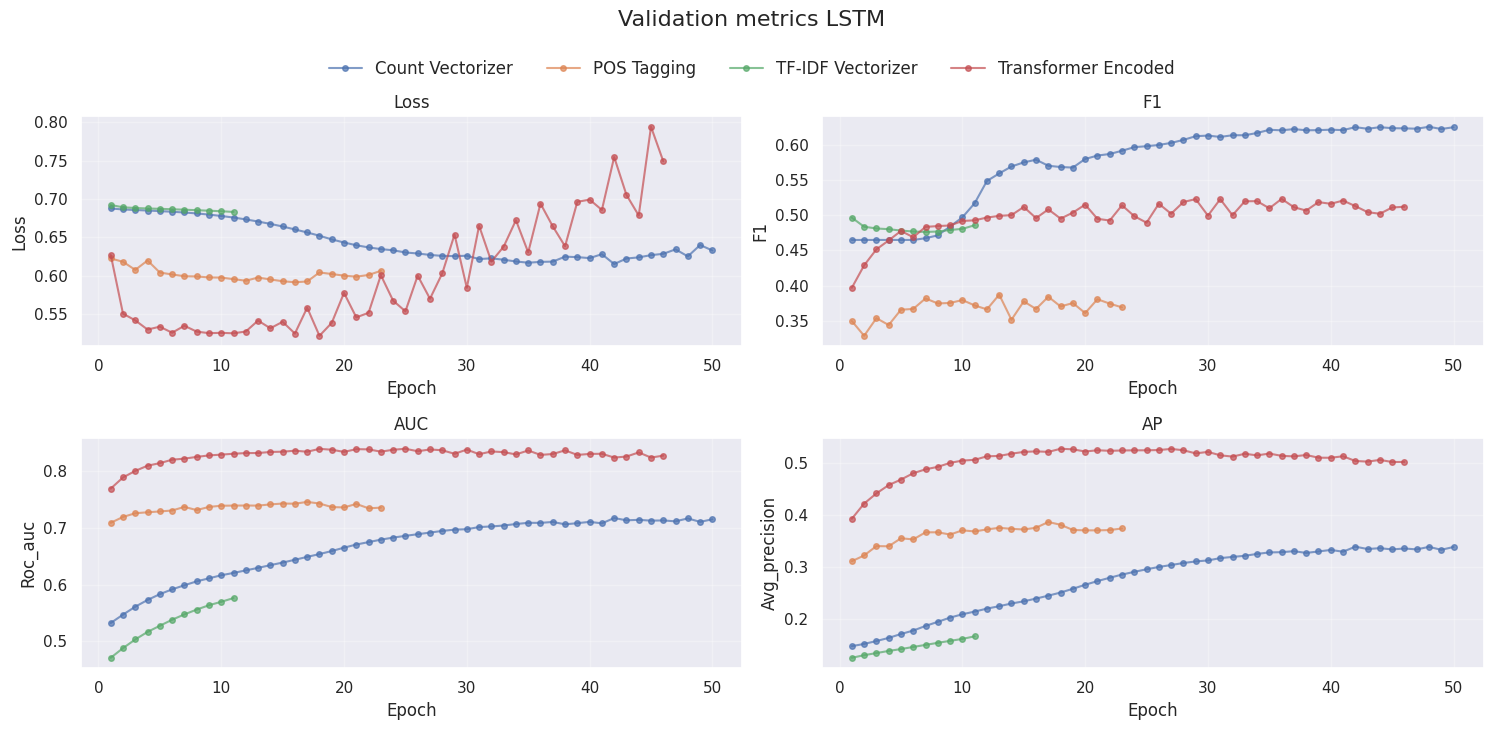

In [137]:
load_plot_rnn(file_paths_LSTM, savename = "pres_LSTM_plots" ,type = "LSTM")

Rrsults
                                   model        f1 precision    recall  \
Count Vectorizer        Count Vectorizer  0.617604  0.613627  0.622269   
POS Tagging                  POS Tagging  0.381356  0.305146  0.508306   
TF-IDF Vectorizer      TF-IDF Vectorizer  0.623822  0.623373  0.624277   
Transformer Encoded  Transformer Encoded  0.507871  0.459184  0.568106   

                      roc_auc avg_precision      loss  
Count Vectorizer     0.706563      0.319894   0.62877  
POS Tagging          0.744637      0.374796  0.606695  
TF-IDF Vectorizer    0.708957      0.325901  0.628129  
Transformer Encoded  0.835794      0.509174   0.58333  


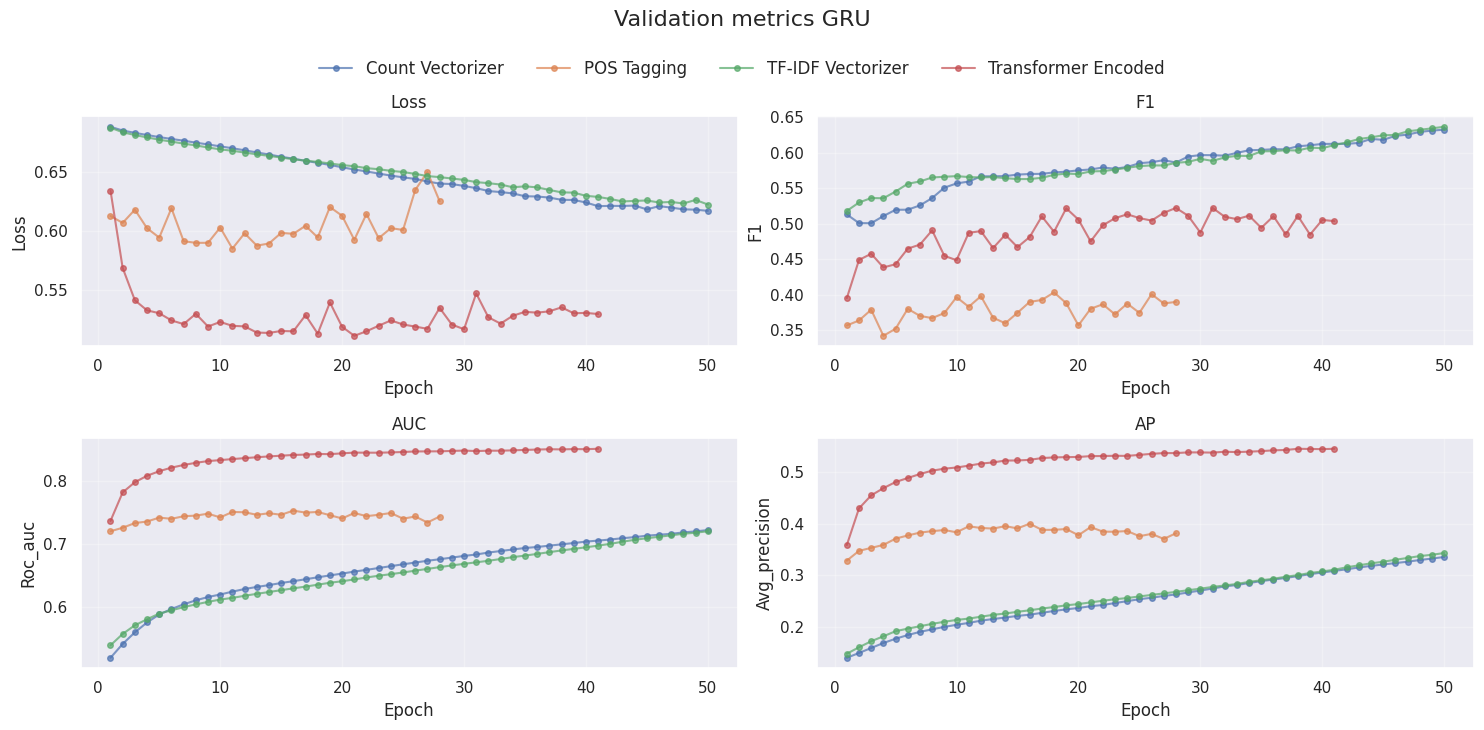

In [138]:
load_plot_rnn(file_paths_GRU, savename= "pres_GRU_plots" ,type = "GRU")

#### Movies

In [139]:
def load_plot_rnn(files_paths, savename = "", type = "GRU"):
    results_pres = {}
    for model_name, file_path in files_paths.items():
        with open(file_path, 'r') as f:
            results_pres[model_name] = json.load(f)

    training_history = {}
    validation_history = {}
    test_metrics = {}

    for model_name, data in results_pres.items():
        print(data)
        train_list = []
        val_list = []
        
        for epoch_data in data['history']:
            epoch = epoch_data['epoch']
            
            train_entry = {'epoch': epoch, 'model': model_name}
            train_entry.update(epoch_data['train'])
            train_list.append(train_entry)
            
            val_entry = {'epoch': epoch, 'model': model_name}
            val_entry.update(epoch_data['val'])
            val_list.append(val_entry)
        
        training_history[model_name] = pd.DataFrame(train_list)
        validation_history[model_name] = pd.DataFrame(val_list)
        
        test_entry = {'model': model_name}
        test_entry.update(data['test'])
        test_metrics[model_name] = test_entry

    train_combined = pd.concat(training_history.values(), ignore_index=True)
    val_combined = pd.concat(validation_history.values(), ignore_index=True)
    test_combined = pd.DataFrame(test_metrics).T

    print("Rrsults")
    print(test_combined)

    # Plot validation metrics comparison
    fig, axes = plt.subplots(2, 2, figsize=(15, 7))

    # metrics_val = ['loss', 'f1', 'precision', 'recall', 'roc_auc', 'avg_precision']
    # titles_val = ['Validation Loss', 'Validation F1', 'Validation Precision', 'Validation Recall', 'Validation AUC', 'Validation AP']
    metrics_val = ['loss', 'f1', 'roc_auc', "accuracy"]
    titles_val = ['Loss', 'F1', 'AUC',  "Accuracy" ]

    for idx, (ax, metric, title) in enumerate(zip(axes.flat, metrics_val, titles_val)):
        for model_name in validation_history.keys():
            df = validation_history[model_name]
            ax.plot(df['epoch'], df[metric], marker='o', label=model_name, alpha=0.7, markersize=4)
        
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.capitalize())
        ax.set_title(title, fontsize=12)
        # ax.legend(loc='best')
        ax.grid(True, alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()

    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.99), 
           ncol=len(validation_history.keys()), fontsize=12, frameon=False)

    plt.suptitle(f"Validation metrics {type}", fontsize=16, y=1.04)
    plt.tight_layout(rect=[0, 0.03, 1, 0.88])

    plt.tight_layout()

    if savename:
        plt.savefig("plots/" + savename + ".pdf", bbox_inches='tight')
    plt.show()

{'run_date': '2026-03-26 17:11:30', 'device': 'cuda', 'vectorizer': {'type': 'count', 'max_features': 10000, 'ngram_range': [1, 1]}, 'model_config': {'rnn_type': 'lstm', 'embed_dim': 32, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.4, 'learning_rate': 1e-05, 'weight_decay': 1e-05, 'early_stopping_patience': 10}, 'best_val_f1': 0.6596638655462185, 'epochs_trained': 11, 'history': [{'epoch': 1, 'train': {'f1': 0.6254335260115607, 'precision': 0.4963302752293578, 'recall': 0.8453125, 'roc_auc': 0.50796630859375, 'accuracy': 0.49375, 'avg_precision': 0.5123279317826006, 'loss': 0.6936963677406311}, 'val': {'f1': 0.6596638655462185, 'precision': 0.49683544303797467, 'recall': 0.98125, 'roc_auc': 0.474375, 'accuracy': 0.49375, 'avg_precision': 0.525476747080018, 'loss': 0.694450831413269}}, {'epoch': 2, 'train': {'f1': 0.6290040768782761, 'precision': 0.5013927576601671, 'recall': 0.84375, 'roc_auc': 0.47498291015625005, 'accuracy': 0.50234375, 'avg_precision': 0.47538191013853287, 'loss'

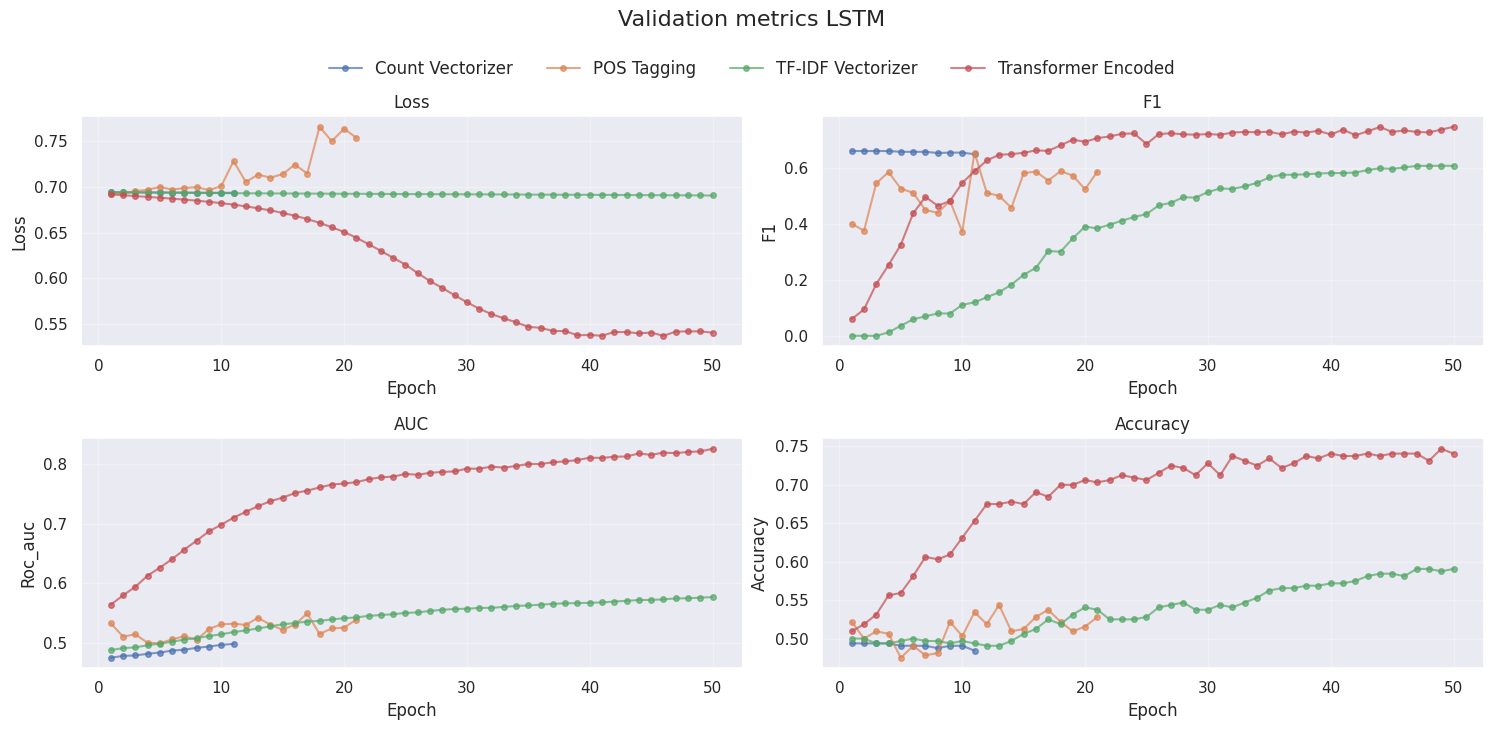

In [140]:
load_plot_rnn(file_paths_LSTM_movies, savename= "movies_LSTM_plots" ,type = "LSTM")

{'run_date': '2026-03-26 17:13:36', 'device': 'cuda', 'vectorizer': {'type': 'count', 'max_features': 10000, 'ngram_range': [1, 1]}, 'model_config': {'rnn_type': 'gru', 'embed_dim': 32, 'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.4, 'learning_rate': 1e-05, 'weight_decay': 1e-05, 'early_stopping_patience': 10}, 'best_val_f1': 0.6306306306306306, 'epochs_trained': 11, 'history': [{'epoch': 1, 'train': {'f1': 0.5892063492063492, 'precision': 0.49625668449197863, 'recall': 0.725, 'roc_auc': 0.509638671875, 'accuracy': 0.49453125, 'avg_precision': 0.5239898333993864, 'loss': 0.6959890127182007}, 'val': {'f1': 0.6306306306306306, 'precision': 0.49295774647887325, 'recall': 0.875, 'roc_auc': 0.40140625, 'accuracy': 0.4875, 'avg_precision': 0.4258466323026886, 'loss': 0.7020275980234146}}, {'epoch': 2, 'train': {'f1': 0.5960179833012202, 'precision': 0.5059978189749182, 'recall': 0.725, 'roc_auc': 0.5340698242187499, 'accuracy': 0.50859375, 'avg_precision': 0.5315722875060847, 'loss': 0.69

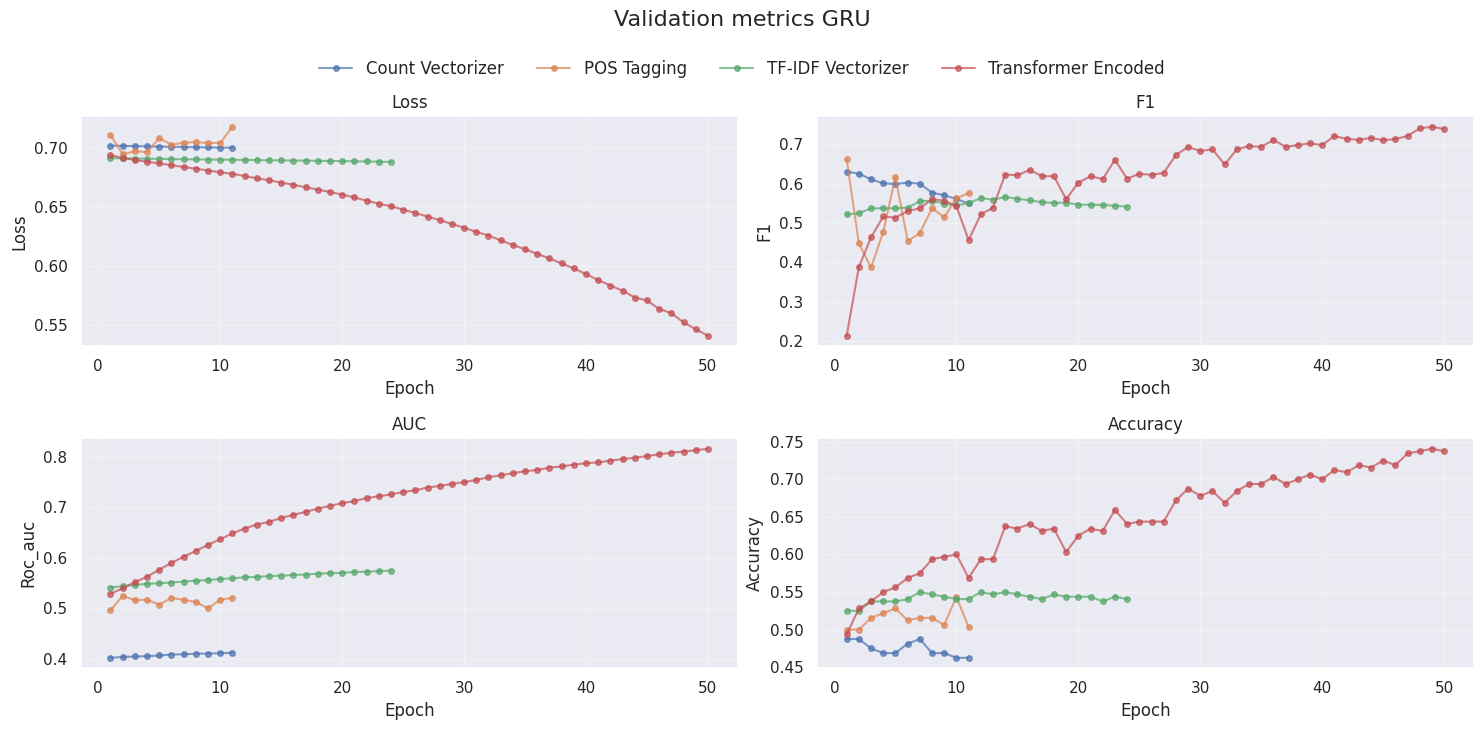

In [141]:
load_plot_rnn(file_paths_GRU_movies, savename= "movies_GRU_plots" ,type = "GRU")

### Plotting transformers

#### President

In [115]:
json_path = Path('results_json/pres_transformer_128_2e-05_camembert-base_results.json')
with open(json_path, 'r') as f:
    results = json.load(f)

In [187]:
def plot_trans(results, savename="", title=""):
    # get data
    train_metrics = []
    val_metrics = []

    for epoch_data in results['history']:
        epoch = epoch_data['epoch']

        train_row = {'epoch': epoch}
        train_row.update(epoch_data['train'])
        train_metrics.append(train_row)

        val_row = {'epoch': epoch}
        val_row.update(epoch_data['val'])
        val_metrics.append(val_row)

    df_train = pd.DataFrame(train_metrics)
    df_val = pd.DataFrame(val_metrics)

    test_metrics = results['test']

    print(df_train)
    print(df_val)
    print(test_metrics)

    # Plot F1 and Loss
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    sns.set_theme(style="darkgrid")

    metrics = ['loss', 'f1', 'avg_precision', 'roc_auc']
    titles = ['Loss ', 'F1 Score', 'Average Precision', 'AUC']

    for i, m in enumerate(metrics):
        ax = axes[i]
        ax.plot(df_train['epoch'], df_train[m], marker='o', label='Train', linewidth=2, color='steelblue')
        ax.plot(df_val['epoch'], df_val[m], marker='s', label='Validation', linewidth=2, color='coral')
        ax.axhline(test_metrics[m], color='green', linestyle='--', linewidth=2, label='Test', alpha=0.7)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(m.replace('_', ' ').title())
        ax.set_title(titles[i])
        # ax.legend()
        ax.grid(alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()

    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.99), 
           ncol=len(results.keys()), fontsize=12, frameon=False)
    
    plt.suptitle(f"{title}", fontsize=16, y=1.04)
    plt.tight_layout(rect=[0, 0.03, 1, 0.88])

    plt.tight_layout()
    if savename:
        plt.savefig(savename + '.pdf', dpi=300, bbox_inches='tight')
    plt.show()

   epoch        f1  precision    recall   roc_auc  avg_precision  accuracy  \
0      1  0.490504   0.520140  0.464062  0.508669       0.504680  0.517969   
1      2  0.587798   0.561080  0.617188  0.592468       0.589498  0.567187   
2      3  0.690363   0.698083  0.682813  0.752603       0.748558  0.693750   
3      4  0.814642   0.812112  0.817187  0.888721       0.883403  0.814063   
4      5  0.881064   0.882445  0.879687  0.942461       0.936176  0.881250   
5      6  0.934375   0.934375  0.934375  0.972043       0.969761  0.934375   
6      7  0.942368   0.939441  0.945312  0.981196       0.977635  0.942187   
7      8  0.971787   0.974843  0.968750  0.992695       0.992695  0.971875   
8      9  0.957413   0.966561  0.948438  0.985183       0.989064  0.957812   

       loss  
0  0.700946  
1  0.680877  
2  0.591648  
3  0.423039  
4  0.303605  
5  0.198858  
6  0.163784  
7  0.098274  
8  0.126863  
   epoch        f1  precision   recall   roc_auc  avg_precision  accuracy  \
0 

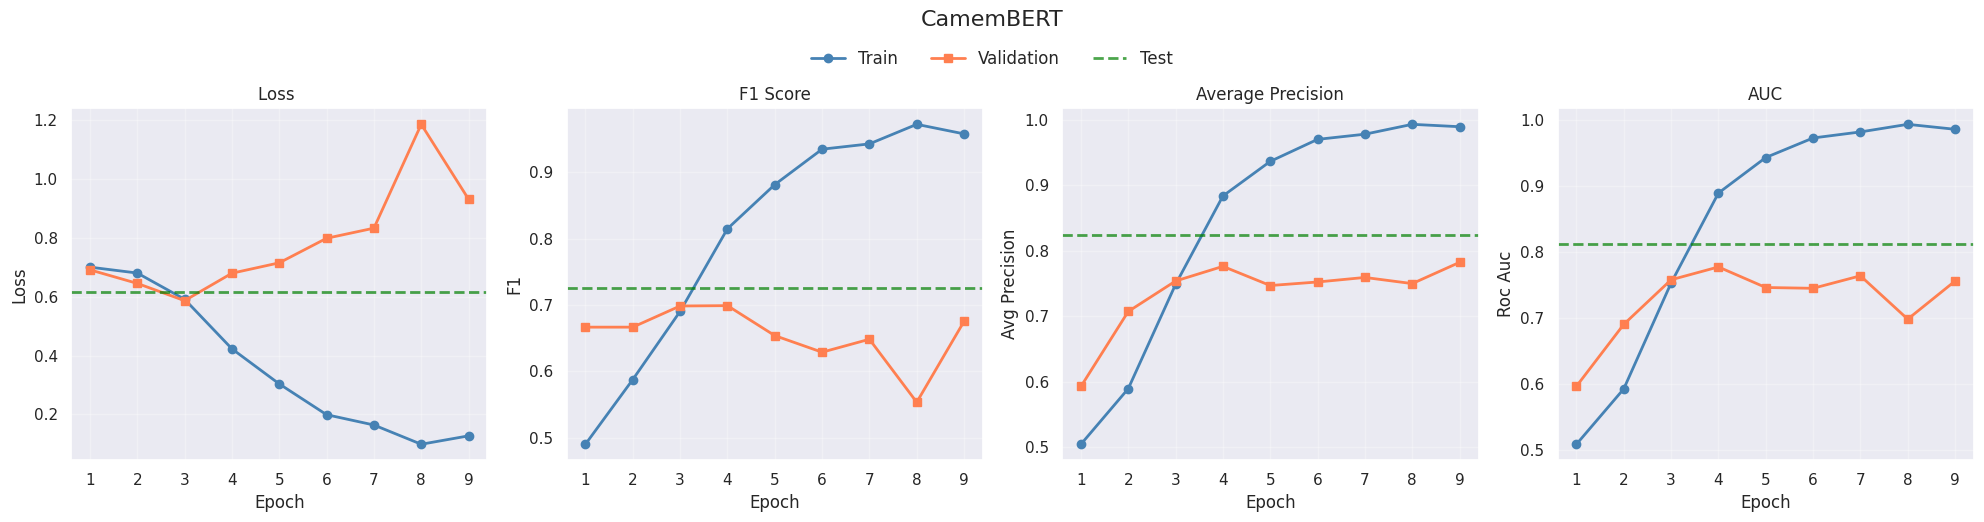

In [176]:
plot_trans(results, savename="plots/pres_transf_camembert_20ep_128ml", title="CamemBERT")

   epoch        f1  precision    recall   roc_auc  avg_precision      loss
0      1  0.455969   0.360551  0.620066  0.813016       0.460359  0.526245
1      2  0.572633   0.453772  0.775862  0.895031       0.655322  0.408178
2      3  0.640156   0.525992  0.817615  0.925929       0.747029  0.341527
3      4  0.690293   0.587070  0.837557  0.941713       0.800439  0.303189
4      5  0.727784   0.630362  0.860823  0.953442       0.830159  0.268575
5      6  0.750825   0.658014  0.874117  0.961899       0.864940  0.240329
6      7  0.782656   0.693567  0.898006  0.967711       0.887446  0.217219
7      8  0.805896   0.720530  0.914209  0.975600       0.909616  0.187079
8      9  0.833744   0.766736  0.913585  0.979147       0.918305  0.171400
9     10  0.842115   0.771988  0.926257  0.981279       0.929683  0.162604
   epoch        f1  precision    recall   roc_auc  avg_precision      loss
0      1  0.600471   0.569196  0.635382  0.879708       0.648950  0.459233
1      2  0.646489   0.62

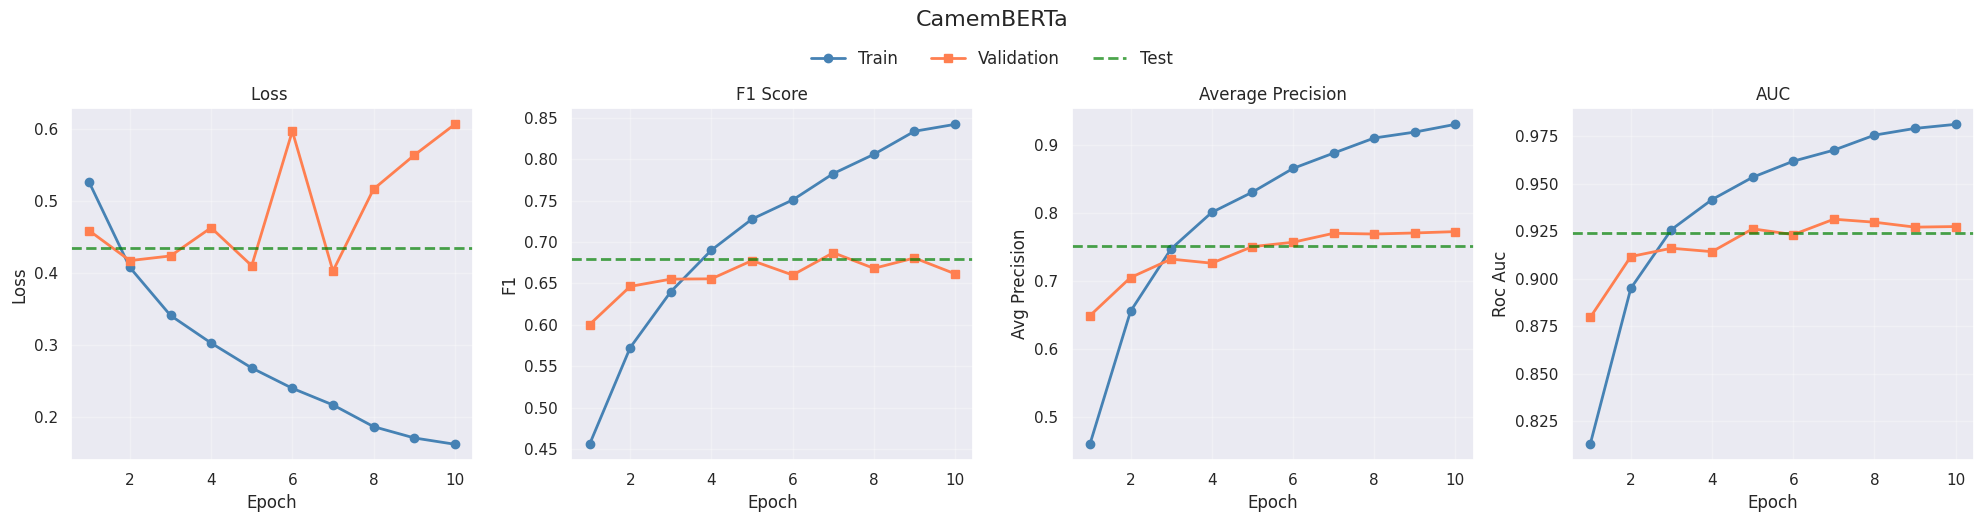

In [188]:
# old president
json_path = Path('rnn/res_json/results_transformer.json')
with open(json_path, 'r') as f:
    results = json.load(f)
plot_trans(results, savename="", title="CamemBERTa")

#### Movies

In [13]:
def plot_trans(results, savename="", title=""):
    # get data
    train_metrics = []
    val_metrics = []

    for epoch_data in results['history']:
        epoch = epoch_data['epoch']

        train_row = {'epoch': epoch}
        train_row.update(epoch_data['train'])
        train_metrics.append(train_row)

        val_row = {'epoch': epoch}
        val_row.update(epoch_data['val'])
        val_metrics.append(val_row)

    df_train = pd.DataFrame(train_metrics)
    df_val = pd.DataFrame(val_metrics)

    test_metrics = results['test']

    print(df_train)
    print(df_val)
    print(test_metrics)

    # Plot F1 and Loss
    metrics = ['loss', 'f1', "accuracy", 'roc_auc']
    titles = ['Loss ', 'F1 Score', "Accuracy",  'AUC']

    fig, axes = plt.subplots(1, len(metrics), figsize=(20, 5))
    sns.set_theme(style="darkgrid")

    for i, m in enumerate(metrics):
        ax = axes[i]
        ax.plot(df_train['epoch'], df_train[m], marker='o', label='Train', linewidth=2, color='steelblue')
        ax.plot(df_val['epoch'], df_val[m], marker='s', label='Validation', linewidth=2, color='coral')
        ax.axhline(test_metrics[m], color='green', linestyle='--', linewidth=2, label='Test', alpha=0.7)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(m.replace('_', ' ').title())
        ax.set_title(titles[i])
        # ax.legend()
        ax.grid(alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()

    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.99), 
           ncol=len(results.keys()), fontsize=12, frameon=False)
    
    plt.suptitle(f"{title}", fontsize=16, y=1.04)
    plt.tight_layout(rect=[0, 0.03, 1, 0.88])

    plt.tight_layout()
    if savename:
        plt.savefig(savename + '.pdf', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
json_path = Path('results_json/movies_transformer_128_2e-05_bert-base-cased_results.json')
with open(json_path, 'r') as f:
    results = json.load(f)

plot_trans(results, savename="plots/movies_trans_bert_20ep_128ml", title="BERT")

    epoch        f1  precision    recall   roc_auc  avg_precision  accuracy  \
0       1  0.522283   0.522692  0.521875  0.530427       0.533000  0.522656   
1       2  0.698891   0.709003  0.689063  0.753059       0.734577  0.703125   
2       3  0.799394   0.775330  0.825000  0.846978       0.828469  0.792969   
3       4  0.840246   0.826284  0.854688  0.905334       0.892468  0.837500   
4       5  0.872308   0.859091  0.885938  0.910383       0.892657  0.870313   
5       6  0.884494   0.895833  0.873437  0.942393       0.945683  0.885938   
6       7  0.921073   0.903759  0.939063  0.955161       0.941916  0.919531   
7       8  0.950896   0.948678  0.953125  0.973684       0.972708  0.950781   
8       9  0.950511   0.955766  0.945312  0.979846       0.977697  0.950781   
9      10  0.975648   0.981043  0.970313  0.993071       0.994223  0.975781   
10     11  0.972050   0.966049  0.978125  0.991006       0.988561  0.971875   
11     12  0.982677   0.990476  0.975000  0.994636  

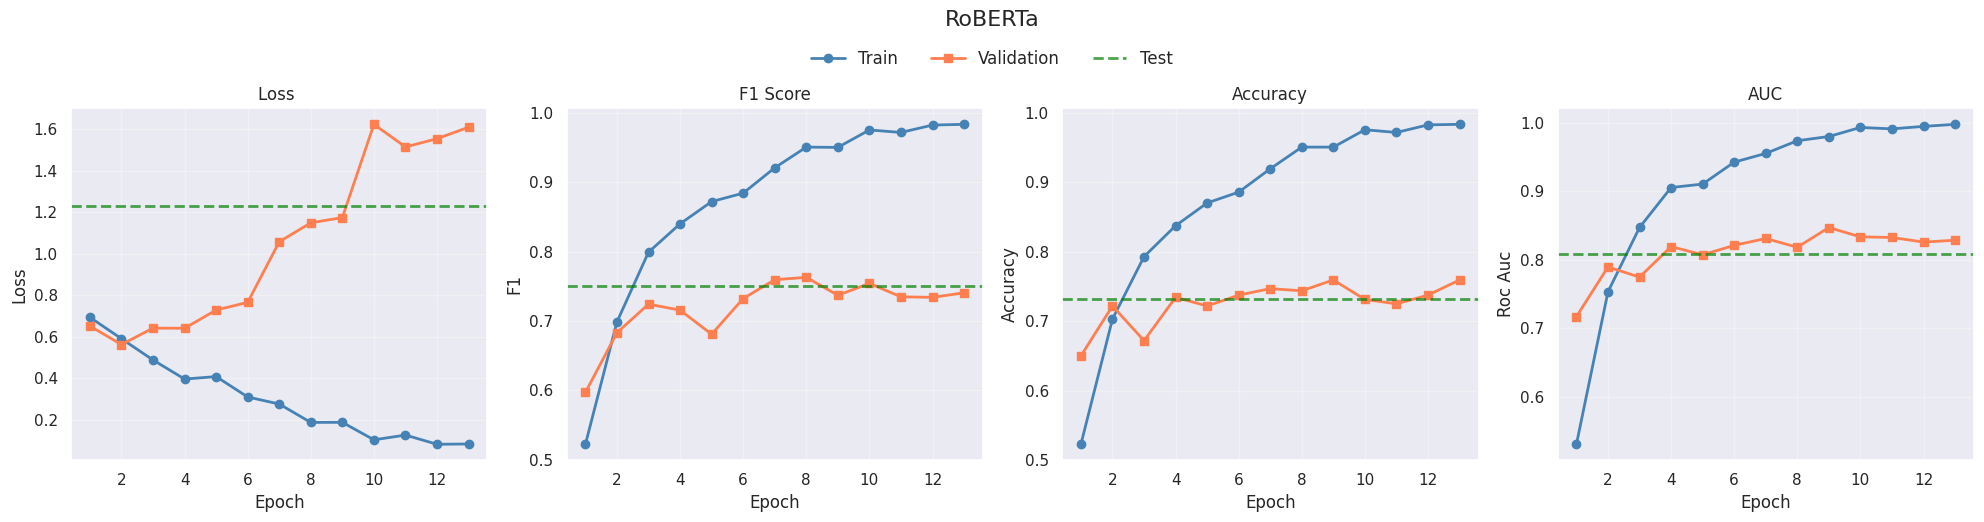

In [18]:
json_path = Path('results_json/movies_transformer_128_2e-05_FacebookAI_roberta-base_results.json')
with open(json_path, 'r') as f:
    results = json.load(f)

plot_trans(results, savename="plots/movies_transformer_128_2e-05_roberta", title="RoBERTa")

    epoch        f1  precision    recall   roc_auc  avg_precision  accuracy  \
0       1  0.645591   0.500430  0.909375  0.495446       0.504379  0.500781   
1       2  0.633562   0.499101  0.867188  0.530210       0.518716  0.498437   
2       3  0.637931   0.504545  0.867188  0.524922       0.535519  0.507812   
3       4  0.620072   0.501934  0.810937  0.514939       0.523434  0.503125   
4       5  0.607389   0.506792  0.757812  0.492690       0.491462  0.510156   
5       6  0.581152   0.500000  0.693750  0.509255       0.515290  0.500000   
6       7  0.600387   0.511551  0.726562  0.527485       0.529132  0.516406   
7       8  0.550409   0.487923  0.631250  0.494985       0.508378  0.484375   
8       9  0.567680   0.508663  0.642188  0.504810       0.509969  0.510938   
9      10  0.535764   0.486005  0.596875  0.477671       0.488246  0.482812   
10     11  0.540767   0.488050  0.606250  0.477476       0.482453  0.485156   
11     12  0.552367   0.510610  0.601562  0.504939  

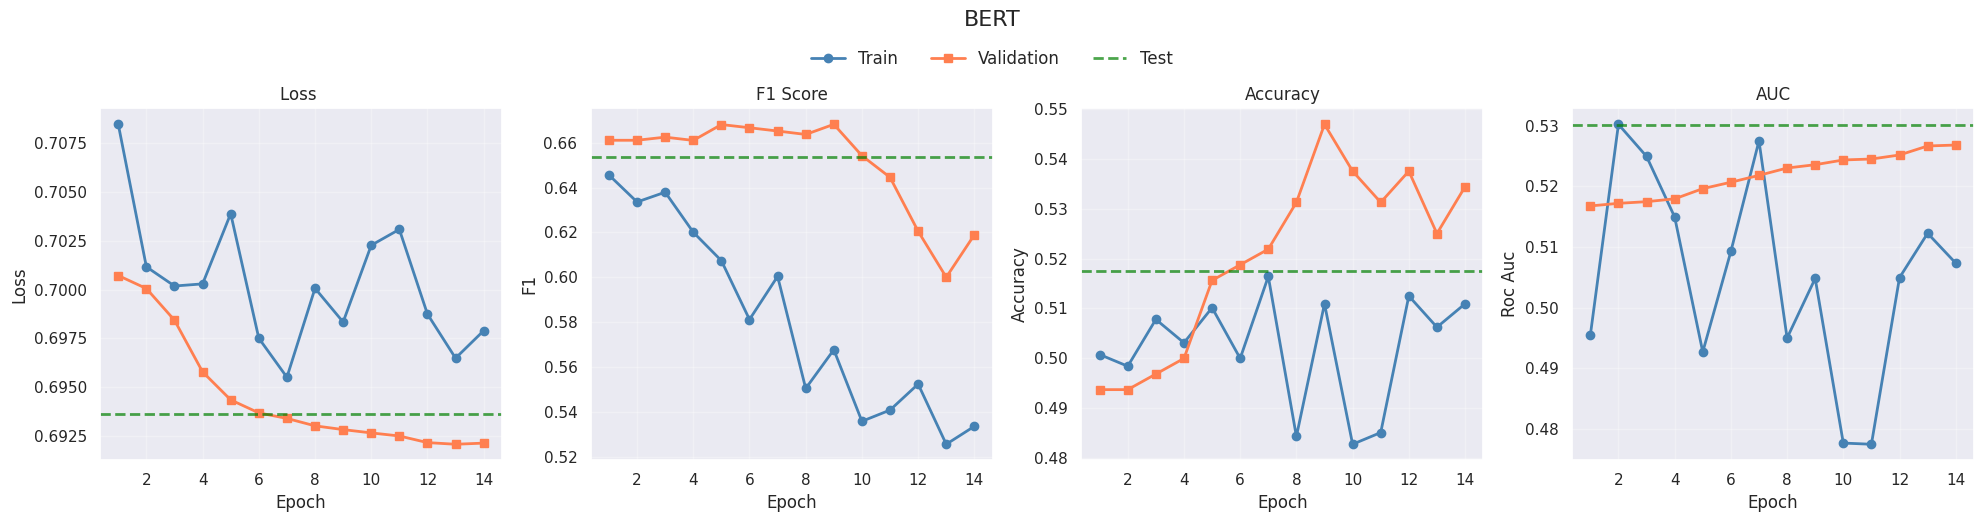

In [19]:
json_path = Path('results_json/movies_transformer_128_2e-06_bert-base-cased_results.json')
with open(json_path, 'r') as f:
    results = json.load(f)

plot_trans(results, savename="plots/movies_transformer_128_2e-06_bert", title="BERT")

    epoch        f1  precision    recall   roc_auc  avg_precision  accuracy  \
0       1  0.644828   0.510000  0.876563  0.526094       0.505821  0.517188   
1       2  0.191067   0.463855  0.120313  0.503914       0.492795  0.490625   
2       3  0.582566   0.533074  0.642188  0.549802       0.545849  0.539844   
3       4  0.532824   0.520896  0.545312  0.528333       0.525276  0.521875   
4       5  0.590595   0.529777  0.667188  0.566580       0.580633  0.537500   
5       6  0.561347   0.576606  0.546875  0.582948       0.566332  0.572656   
6       7  0.497854   0.552381  0.453125  0.580684       0.565408  0.542969   
7       8  0.515679   0.582677  0.462500  0.606865       0.572406  0.565625   
8       9  0.487204   0.619277  0.401562  0.623474       0.588446  0.577344   
9      10  0.528029   0.626609  0.456250  0.641448       0.612320  0.592187   
10     11  0.406383   0.636667  0.298438  0.628770       0.616073  0.564063   
11     12  0.634146   0.586207  0.690625  0.645393  

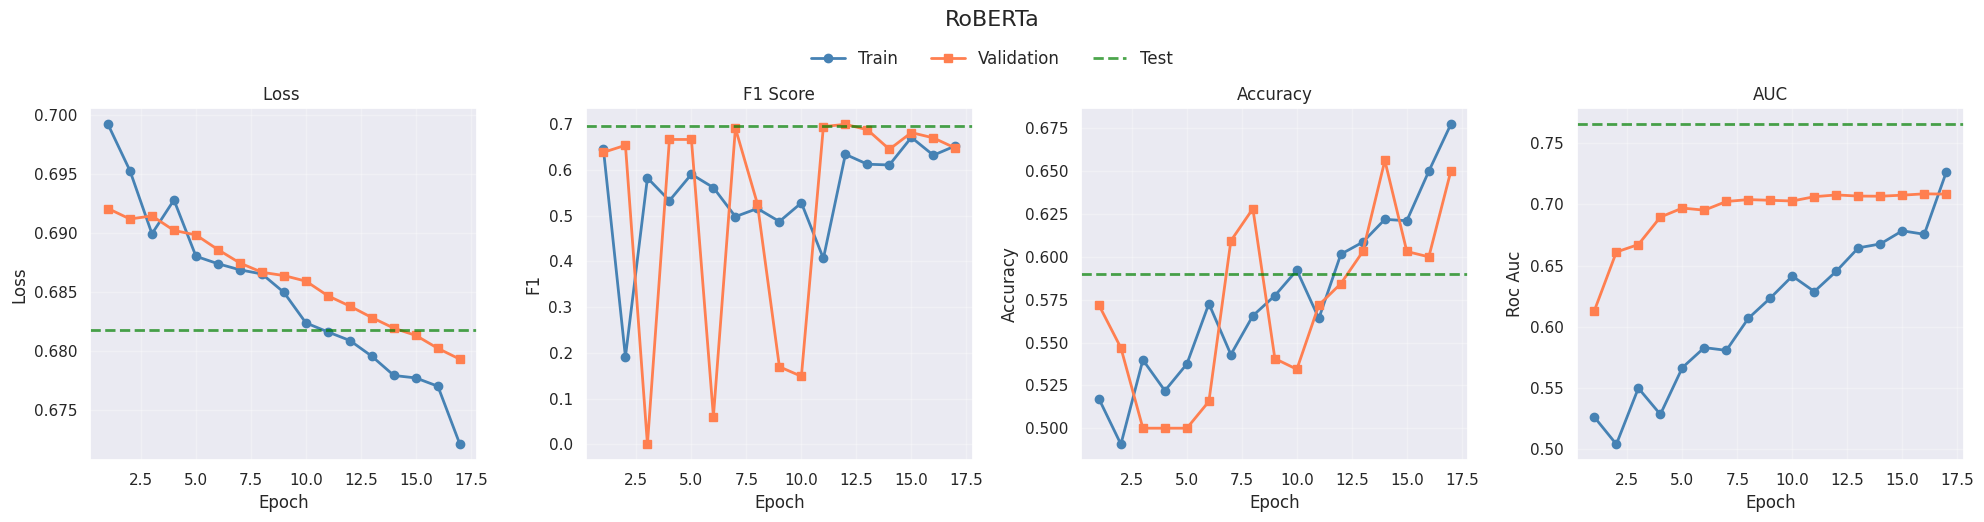

In [20]:
json_path = Path('results_json/movies_transformer_256_2e-05_FacebookAI_roberta-base_results.json')
with open(json_path, 'r') as f:
    results = json.load(f)

plot_trans(results, savename="plots/movies_transformer_256_2e-05_roberta", title="RoBERTa")

   epoch        f1  precision    recall   roc_auc  avg_precision  accuracy  \
0      1  0.559066   0.498775  0.635938  0.503643       0.501954  0.498437   
1      2  0.595520   0.514806  0.706250  0.517761       0.517115  0.520312   
2      3  0.559033   0.513055  0.614062  0.511838       0.515785  0.515625   
3      4  0.520290   0.485135  0.560937  0.489216       0.497839  0.482812   
4      5  0.550143   0.507937  0.600000  0.530548       0.528845  0.509375   
5      6  0.540126   0.488020  0.604688  0.497815       0.496439  0.485156   

       loss  
0  0.693804  
1  0.693276  
2  0.693047  
3  0.695114  
4  0.692011  
5  0.694610  
   epoch        f1  precision   recall   roc_auc  avg_precision  accuracy  \
0      1  0.666667   0.500000  1.00000  0.508867       0.523095  0.500000   
1      2  0.666667   0.500000  1.00000  0.519121       0.531418  0.500000   
2      3  0.656716   0.498382  0.96250  0.529414       0.540802  0.496875   
3      4  0.645022   0.493377  0.93125  0.53691

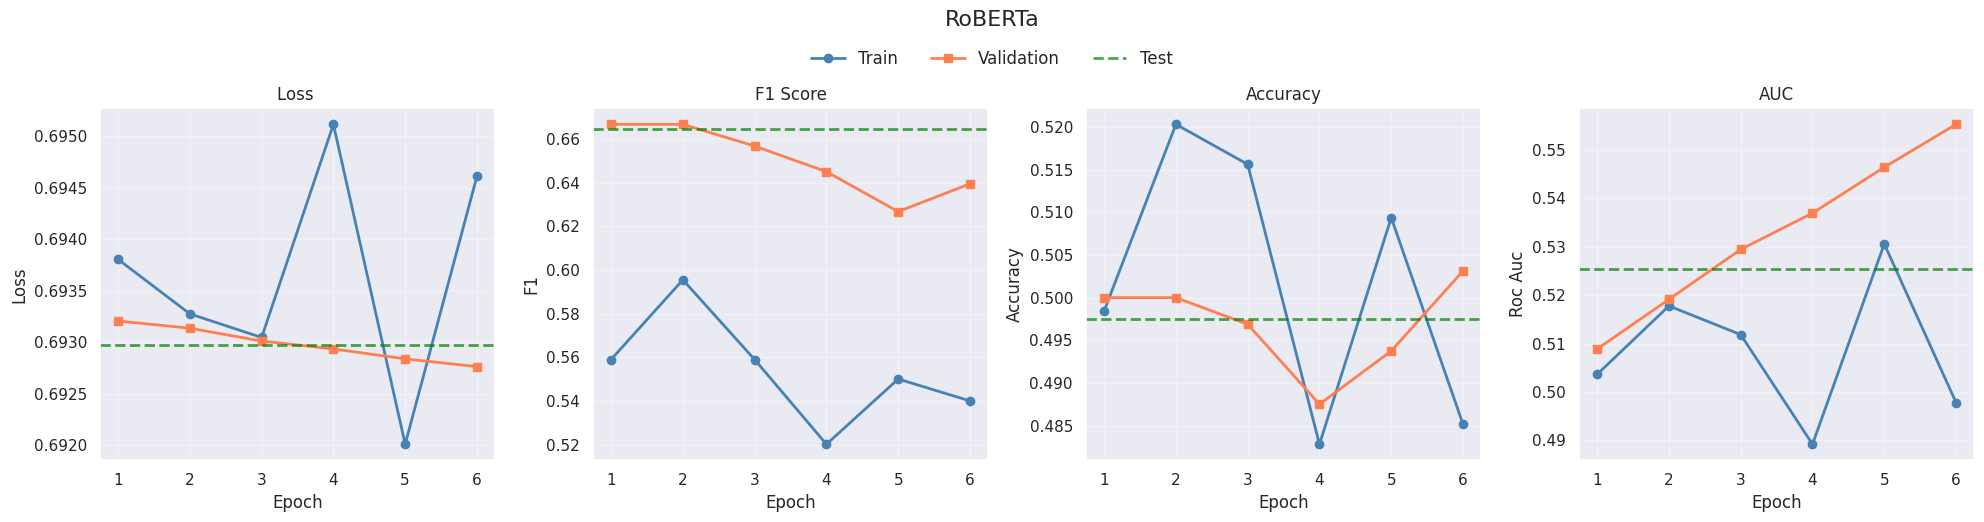

In [21]:
json_path = Path('results_json/movies_transformer_256_2e-06_FacebookAI_roberta-base_results.json')
with open(json_path, 'r') as f:
    results = json.load(f)

plot_trans(results, savename="plots/movies_transformer_256_2e-06_roberta", title="RoBERTa")

    epoch        f1  precision    recall   roc_auc  avg_precision  accuracy  \
0       1  0.649186   0.770386  0.560937  0.789614       0.788269  0.696875   
1       2  0.880821   0.889952  0.871875  0.929766       0.921889  0.882031   
2       3  0.907975   0.891566  0.925000  0.951436       0.942884  0.906250   
3       4  0.949099   0.951334  0.946875  0.969858       0.971933  0.949219   
4       5  0.957265   0.952087  0.962500  0.979036       0.979032  0.957031   
5       6  0.967843   0.971654  0.964063  0.984038       0.985961  0.967969   
6       7  0.965079   0.980645  0.950000  0.983394       0.985700  0.965625   
7       8  0.971743   0.976341  0.967187  0.996035       0.996524  0.971875   
8       9  0.977147   0.985692  0.968750  0.991740       0.989986  0.977344   
9      10  0.981221   0.982759  0.979688  0.990776       0.989585  0.981250   
10     11  0.990610   0.992163  0.989062  0.995735       0.997509  0.990625   
11     12  0.994544   0.992224  0.996875  0.998328  

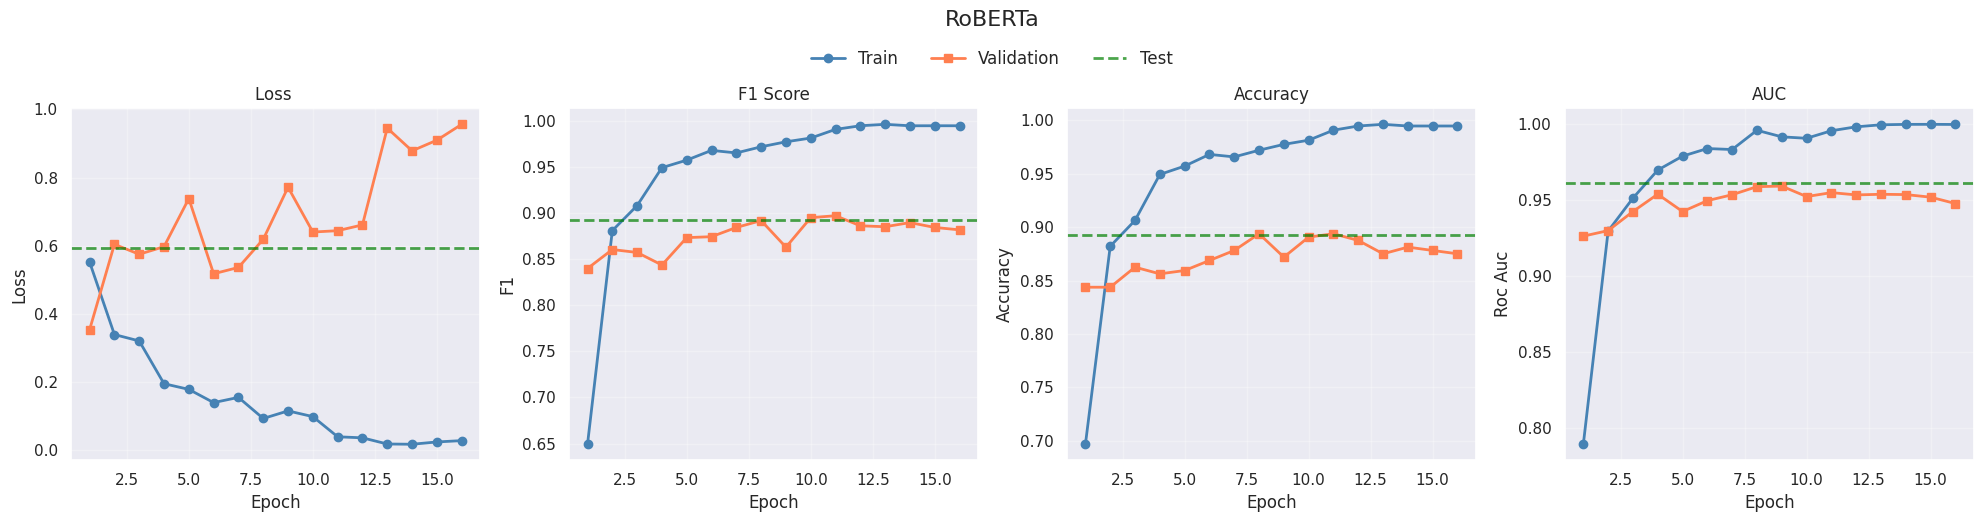

In [22]:
json_path = Path('results_json/movies_transformer_512_2e-05_FacebookAI_roberta-base_results.json')
with open(json_path, 'r') as f:
    results = json.load(f)

plot_trans(results, savename="plots/movies_transformer_512_2e-05_roberta", title="RoBERTa")

   epoch        f1  precision    recall   roc_auc  avg_precision  accuracy  \
0      1  0.663527   0.498820  0.990625  0.487239       0.502932  0.497656   
1      2  0.664222   0.499606  0.990625  0.478000       0.481233  0.499219   
2      3  0.660667   0.499600  0.975000  0.521592       0.522153  0.499219   
3      4  0.662753   0.503241  0.970313  0.501985       0.506775  0.506250   
4      5  0.656604   0.501235  0.951562  0.503096       0.504496  0.502344   
5      6  0.645626   0.500000  0.910937  0.501875       0.513190  0.500000   

       loss  
0  0.734519  
1  0.730595  
2  0.717450  
3  0.715692  
4  0.711486  
5  0.707644  
   epoch        f1  precision   recall   roc_auc  avg_precision  accuracy  \
0      1  0.666667   0.500000  1.00000  0.520937       0.512382  0.500000   
1      2  0.666667   0.500000  1.00000  0.522305       0.513787  0.500000   
2      3  0.666667   0.500000  1.00000  0.523555       0.514723  0.500000   
3      4  0.666667   0.500000  1.00000  0.52410

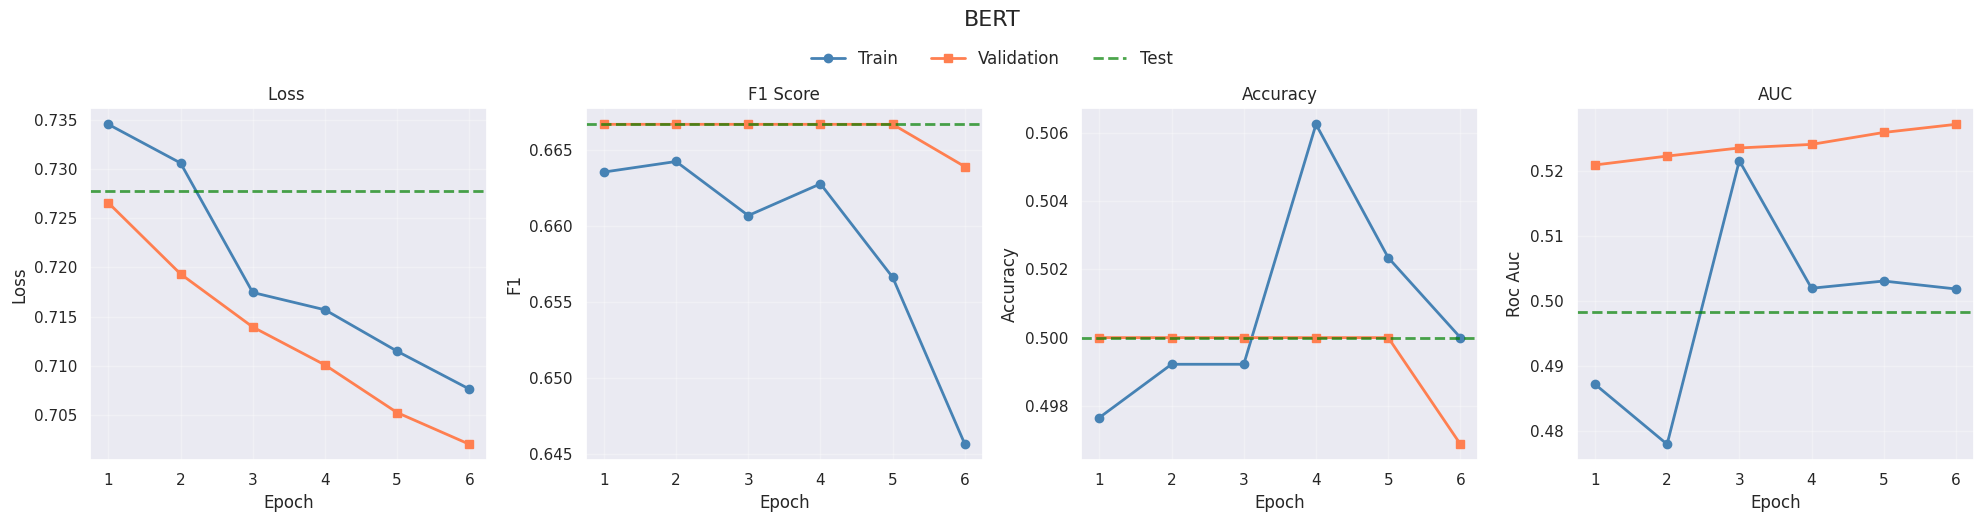

In [23]:
json_path = Path('results_json/movies_transformer_512_2e-06_bert-base-cased_results.json')
with open(json_path, 'r') as f:
    results = json.load(f)

plot_trans(results, savename="plots/movies_transformer_512_2e-06_bert", title="BERT")

### Plotting simple models grid search

In [183]:
# for president the file was ran twice
dataset = "president"

if dataset == "president":
    with open('rnn/res_json/model_test_results_20260324_004319.json', 'r') as f:
        ml_results_basic = json.load(f)

    # Load Linear SVM results
    with open('rnn/res_json/model_test_results_lin_scv_20260324_122136.json', 'r') as f:
        ml_results_linear_svm = json.load(f)

else:
    with open('results_json/movies_simple_model_20260326_124819.json', 'r') as f:
        ml_results_basic = json.load(f)

#    # Load Linear SVM results
#    with open('rnn/res_json/model_test_results_movies_lin_scv_20260324_122136.json', 'r') as f:
#        ml_results_linear_svm = json.load(f)

In [184]:
ml_basic_df = pd.DataFrame([
    {
        'prep': r['prep'],
        'vectorizer': r['vectorizer'],
        'model': r['model'],
        'status': r['status'],
        **{f'cv_{k}': v for k, v in r.get('cv_metrics', {}).items()},
        **{f'test_{k}': v for k, v in r.get('test_metrics', {}).items()}
    }
    for r in ml_results_basic
])

ml_combined = ml_basic_df.copy() 

if dataset == "president":
    ml_linear_svm_df = pd.DataFrame([
        {
            'prep': r['prep'],
            'vectorizer': r['vectorizer'],
            'model': 'linear_svm', 
            'status': r['status'],
            **{f'cv_{k}': v for k, v in r.get('cv_metrics', {}).items()},
            **{f'test_{k}': v for k, v in r.get('test_metrics', {}).items()}
        }
        for r in ml_results_linear_svm
    ])

    ml_basic_success = ml_basic_df[ml_basic_df['status'] == 'success'].copy() # svc failed heree
    ml_combined = pd.concat([ml_basic_success, ml_linear_svm_df], ignore_index=True)
print(ml_combined)

           prep     vectorizer                model   status  cv_f1_macro  \
0   basic_lower  count_unigram          naive_bayes  success     0.662018   
1   basic_lower  count_unigram  logistic_regression  success     0.670797   
2   basic_lower  count_unigram              svm_rbf  success     0.641411   
3   basic_lower  count_unigram        random_forest  success     0.573271   
4   basic_lower   count_bigram          naive_bayes  success     0.663102   
5   basic_lower   count_bigram  logistic_regression  success     0.674876   
6   basic_lower   count_bigram              svm_rbf  success     0.659950   
7   basic_lower   count_bigram        random_forest  success     0.587508   
8   basic_lower  tfidf_unigram          naive_bayes  success     0.661227   
9   basic_lower  tfidf_unigram  logistic_regression  success     0.668821   
10  basic_lower  tfidf_unigram              svm_rbf  success     0.634579   
11  basic_lower  tfidf_unigram        random_forest  success     0.575441   

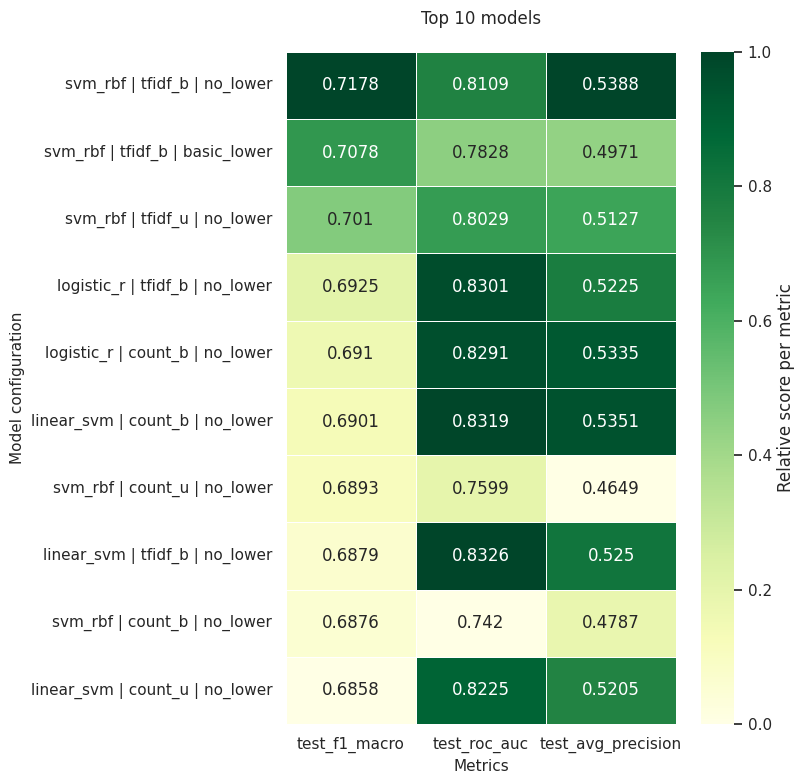

In [185]:
# plotting the top 10 models by f1
top_10 = ml_combined.nlargest(10, 'test_f1_macro')

# Select key metrics and normalize
metrics = ['test_f1_macro', 'test_roc_auc', 'test_avg_precision'] #  'test_recall_macro', 'test_precision_macro'
heatmap_data = top_10[['model', 'vectorizer', 'prep'] + metrics].copy()

# Create display labels
heatmap_data['config'] = (heatmap_data['model'].str[:10] + ' | ' + 
                          heatmap_data['vectorizer'].str[:7] + ' | ' + 
                          heatmap_data['prep'].str[:11])

# Normalize metrics to 0-1 range for better visualization
normalized_data = heatmap_data[metrics].copy()
for col in metrics:
    col_min = normalized_data[col].min()
    col_max = normalized_data[col].max()
    if col_max > col_min:
        normalized_data[col] = (normalized_data[col] - col_min) / (col_max - col_min)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(normalized_data.set_index(heatmap_data['config']), 
            annot=heatmap_data[metrics].round(4).values, 
            fmt='g', cmap='YlGn', cbar_kws={'label': 'Relative score per metric'}, ax=ax, linewidths=0.5) #YlOrRd
ax.set_title('Top 10 models', fontsize=12, pad=20)
ax.set_xlabel('Metrics',  fontsize=11)
ax.set_ylabel('Model configuration', fontsize=11)
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
# plt.savefig("images/top_10_models_heatmap.pdf", dpi=300)
plt.show()